<a href="https://colab.research.google.com/github/tojotk/IMDb_Movie_Reviews/blob/Model-Building/IMDb_Movie_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
pip install gensim

# Libraries

In [103]:
# Data manipulation and numerical computations
import pandas as pd
import numpy as np

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing utilities
import re
import string
import nltk

# Natural Language Processing (NLP) resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

# Specific NLP preprocessing modules
from nltk.tokenize import word_tokenize # For splitting text into words
from nltk.corpus import stopwords       # For filtering common words
from nltk.stem import PorterStemmer     # For reducing words to their root form
from nltk.stem import WordNetLemmatizer # For reducing words to their base form (lemma)

# Scikit-learn for machine learning utilities
from sklearn.preprocessing import LabelEncoder # To convert categorical labels to numerical
from sklearn.model_selection import train_test_split # To split dataset for training and testing
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer # To convert text to numerical features

# Model evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Machine Learning model algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Gensim for Word2Vec embeddings
from gensim.models import Word2Vec

# TensorFlow/Keras for deep learning models
from tensorflow.keras.preprocessing.text import Tokenizer          # For text tokenization
from tensorflow.keras.preprocessing.sequence import pad_sequences  # For sequence padding

# Keras layers for building the neural network
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Concatenate

# Keras Model API for defining custom models
from tensorflow.keras.models import Model

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Read dataset

In [104]:
df_movie = pd.read_csv('/content/drive/MyDrive/AI ML Course/Data/IMDB Dataset.csv')
df_movie.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# EDA

In [105]:
df_movie.shape

(50000, 2)

In [106]:
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [107]:
df_movie.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [108]:
df_movie.isnull().sum()

,0
review,0
sentiment,0


In [109]:
# view sentiment distrubution
df_movie["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


## Plot Visualization

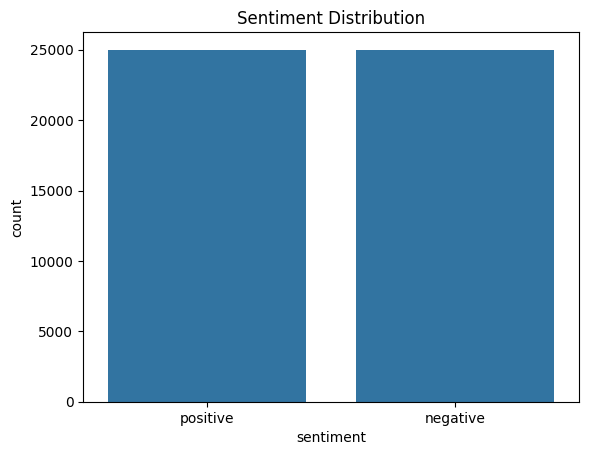

In [110]:
# Draw bar chart
sns.countplot(x="sentiment", data=df_movie)
plt.title("Sentiment Distribution")
plt.show()

In [111]:
# Checking review length

In [112]:
# Count number of words in each review
df_movie["Review_Length"] = df_movie["review"].apply(lambda x: len(x.split()))
df_movie["Review_Length"].head()

,Review_Length
0,307
1,162
2,166
3,138
4,230


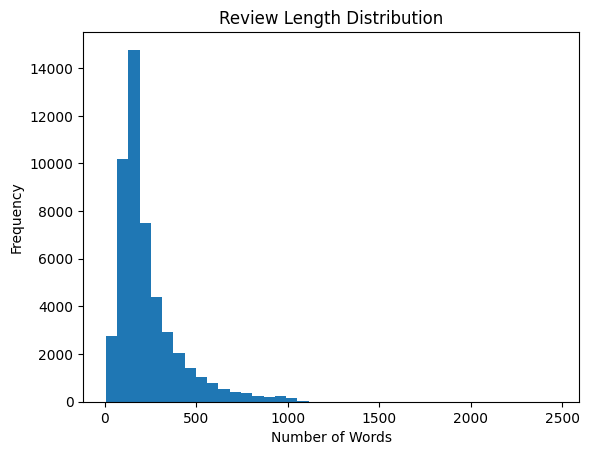

In [113]:
# Plot histogram
plt.hist(df_movie["Review_Length"], bins=40)
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Review Length Distribution")

plt.show()

# Text Preprocessing

## Duplicates removal

In [114]:
df_movie.duplicated().sum()

np.int64(418)

In [115]:
df_movie.drop_duplicates(inplace=True)

In [116]:
df_movie.duplicated().sum()

np.int64(0)

## Missing value

In [117]:
df_movie.isnull().sum()

,0
review,0
sentiment,0
Review_Length,0


## Remove html tags

In [118]:
# Function to remove HTML tags
def remove_html(text):
    clean = re.compile("<.*?>")
    return re.sub(clean, "", text)
df_movie["review"] = df_movie["review"].apply(remove_html)

## Convert to lowercase

In [119]:
# Convert all text into lowercase
df_movie["review"] = df_movie["review"].str.lower()

## Remove Punctuations

In [120]:
# Function to remove punctuation
def remove_punctuation(text):
    # Remove punctuation characters
    return text.translate(str.maketrans("", "", string.punctuation))
df_movie["review"] = df_movie["review"].apply(remove_punctuation)

## Tokenization

In [121]:
# Convert sentence into list of words
df_movie["Tokens"] = df_movie["review"].apply(word_tokenize)
# Display first review tokens
df_movie["Tokens"].head()

,Tokens
0,"[one, of, the, other, reviewers, has, mentione..."
1,"[a, wonderful, little, production, the, filmin..."
2,"[i, thought, this, was, a, wonderful, way, to,..."
3,"[basically, theres, a, family, where, a, littl..."
4,"[petter, matteis, love, in, the, time, of, mon..."


## Remove Stopwords

In [122]:
# Load  stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords
df_movie["Tokens"] = df_movie["Tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

## Stemming

In [123]:
# Create stemmer object
stemmer = PorterStemmer()

# Apply stemming
df_movie["Stemmed"] = df_movie["Tokens"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

## Lemmatization

In [124]:
# Create lemmatizer object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df_movie["Lemmatized"] = df_movie["Tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

## Convert tokens back to sentence

In [125]:
# Join words into a sentence
df_movie["Clean_Review"] = df_movie["Lemmatized"].apply(lambda words: " ".join(words))

# Display cleaned reviews
df_movie[["review", "Clean_Review"]].head()

,review,Clean_Review
0,one of the other reviewers has mentioned that ...,one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...


In [126]:
df_movie.head()

,review,sentiment,Review_Length,Tokens,Stemmed,Lemmatized,Clean_Review
0,one of the other reviewers has mentioned that ...,positive,307,"[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, y...","[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,positive,162,"[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,positive,166,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,negative,138,"[basically, theres, family, little, boy, jake,...","[basic, there, famili, littl, boy, jake, think...","[basically, there, family, little, boy, jake, ...",basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,positive,230,"[petter, matteis, love, time, money, visually,...","[petter, mattei, love, time, money, visual, st...","[petter, matteis, love, time, money, visually,...",petter matteis love time money visually stunni...


Esha

## Split Features and Target

In [127]:
# Define the input feature (cleaned review text)
# and the target variable (sentiment).

X = df_movie["Clean_Review"]

y = df_movie["sentiment"]

## Train-Test Split

In [128]:
# Split the dataset into training and testing sets.
# Stratify ensures both sets maintain the same proportion of positive and negative reviews.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Display the size of the training and testing datasets.
print(X_train.shape)
print(X_test.shape)

(39665,)
(9917,)


## Encode the Target Variable

In [129]:
# Convert the target labels ('positive' and 'negative')
# into numerical values (1 and 0) for machine learning models.
label_enc = LabelEncoder()

df_movie["sentiment"] = label_enc.fit_transform(df_movie["sentiment"])
# Display the number of positive and negative reviews.
df_movie["sentiment"].value_counts()

,count
sentiment,
1,24884
0,24698


In [130]:
df_movie.head(3)

,review,sentiment,Review_Length,Tokens,Stemmed,Lemmatized,Clean_Review
0,one of the other reviewers has mentioned that ...,1,307,"[one, reviewers, mentioned, watching, 1, oz, e...","[one, review, mention, watch, 1, oz, episod, y...","[one, reviewer, mentioned, watching, 1, oz, ep...",one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production the filming tech...,1,162,"[wonderful, little, production, filming, techn...","[wonder, littl, product, film, techniqu, unass...","[wonderful, little, production, filming, techn...",wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,1,166,"[thought, wonderful, way, spend, time, hot, su...","[thought, wonder, way, spend, time, hot, summe...","[thought, wonderful, way, spend, time, hot, su...",thought wonderful way spend time hot summer we...


# Feature Engineering

##. CountVectorizer — Bag of Words

In [131]:
count_vectorizer = CountVectorizer(
    max_features=20000,
    ngram_range=(1, 1)
)

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Training matrix:", X_train_count.shape)
print("Testing matrix:", X_test_count.shape)

Training matrix: (39665, 20000)
Testing matrix: (9917, 20000)


###Logistic Regression using CountVectorizer

In [132]:
lr_count = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_count.fit(X_train_count, y_train)

y_pred_lr_count = lr_count.predict(X_test_count)

accuracy_lr_count = accuracy_score(
    y_test,
    y_pred_lr_count
)

print("Logistic Regression Accuracy:",
      accuracy_lr_count)

Logistic Regression Accuracy: 0.8772814359181204


###Multinomial Naive Bayes

In [133]:
nb_count = MultinomialNB()

nb_count.fit(X_train_count, y_train)

y_pred_nb_count = nb_count.predict(X_test_count)

accuracy_nb_count = accuracy_score(
    y_test,
    y_pred_nb_count
)

print("Naive Bayes Accuracy:",
      accuracy_nb_count)

Naive Bayes Accuracy: 0.8511646667338914


###Linear SVM

In [134]:
svm_count = LinearSVC(
    random_state=42
)

svm_count.fit(X_train_count, y_train)

y_pred_svm_count = svm_count.predict(X_test_count)

accuracy_svm_count = accuracy_score(
    y_test,
    y_pred_svm_count
)

print("Linear SVM Accuracy:",
      accuracy_svm_count)

Linear SVM Accuracy: 0.8507613189472623


###Random Forest

In [135]:
rf_count = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_count.fit(X_train_count, y_train)

y_pred_rf_count = rf_count.predict(X_test_count)

accuracy_rf_count = accuracy_score(
    y_test,
    y_pred_rf_count
)

print("Random Forest Accuracy:",
      accuracy_rf_count)

Random Forest Accuracy: 0.8543914490269234


###Compare CountVectorizer Models

In [136]:
count_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Linear SVM',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr_count,
        accuracy_nb_count,
        accuracy_svm_count,
        accuracy_rf_count
    ]
})

count_results

,Model,Accuracy
0,Logistic Regression,0.877281
1,Naive Bayes,0.851165
2,Linear SVM,0.850761
3,Random Forest,0.854391


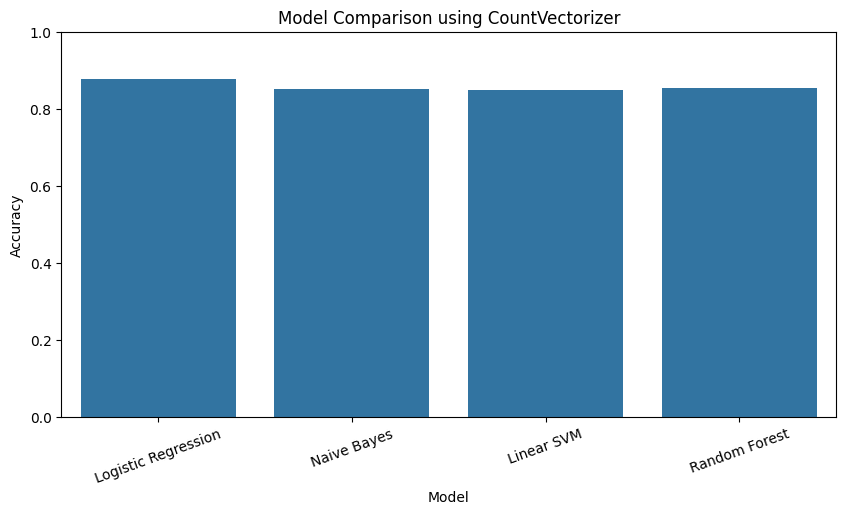

In [137]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=count_results
)

plt.title('Model Comparison using CountVectorizer')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

## TF-IDF

TF-IDF assigns importance to words based on how frequently they
appear in a document while reducing the importance of words that
occur across many documents.

In [138]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training matrix:", X_train_tfidf.shape)
print("Testing matrix:", X_test_tfidf.shape)

Training matrix: (39665, 30000)
Testing matrix: (9917, 30000)


## Train Logistic Regression

In [139]:
lr_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_tfidf.fit(X_train_tfidf, y_train)

y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

accuracy_lr_tfidf = accuracy_score(
    y_test,
    y_pred_lr_tfidf
)

print("Logistic Regression Accuracy:",
      accuracy_lr_tfidf)

Logistic Regression Accuracy: 0.8964404557829989


###Naive Bayes with TF-IDF

In [140]:
nb_tfidf = MultinomialNB()

nb_tfidf.fit(X_train_tfidf, y_train)

y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

accuracy_nb_tfidf = accuracy_score(
    y_test,
    y_pred_nb_tfidf
)

print("Naive Bayes Accuracy:",
      accuracy_nb_tfidf)

Naive Bayes Accuracy: 0.8787939901179792


###Linear SVM with TF-IDF

In [141]:
svm_tfidf = LinearSVC(
    random_state=42
)

svm_tfidf.fit(X_train_tfidf, y_train)

y_pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)

accuracy_svm_tfidf = accuracy_score(
    y_test,
    y_pred_svm_tfidf
)

print("Linear SVM Accuracy:",
      accuracy_svm_tfidf)

Linear SVM Accuracy: 0.8967429666229707


###Random Forest with TF-IDF

In [142]:
rf_tfidf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_tfidf.fit(X_train_tfidf, y_train)

y_pred_rf_tfidf = rf_tfidf.predict(X_test_tfidf)

accuracy_rf_tfidf = accuracy_score(
    y_test,
    y_pred_rf_tfidf
)

print("Random Forest Accuracy:",
      accuracy_rf_tfidf)

Random Forest Accuracy: 0.8560048401734396


##Compare All TF-IDF Models

In [143]:
tfidf_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Linear SVM',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_lr_tfidf,
        accuracy_nb_tfidf,
        accuracy_svm_tfidf,
        accuracy_rf_tfidf
    ]
})

tfidf_results

,Model,Accuracy
0,Logistic Regression,0.896440
1,Naive Bayes,0.878794
2,Linear SVM,0.896743
3,Random Forest,0.856005


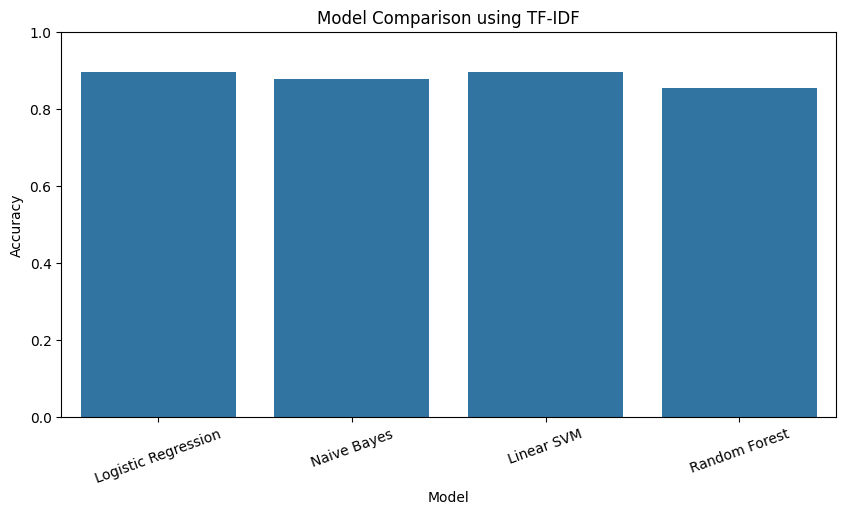

In [144]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=tfidf_results
)

plt.title('Model Comparison using TF-IDF')
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.show()

##N-Gram Analysis

In [145]:
ngram_vectorizer = CountVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

X_train_ngram = ngram_vectorizer.fit_transform(X_train)
X_test_ngram = ngram_vectorizer.transform(X_test)

print("Training matrix:", X_train_ngram.shape)
print("Testing matrix:", X_test_ngram.shape)

Training matrix: (39665, 20000)
Testing matrix: (9917, 20000)


In [146]:
svm_ngram = LinearSVC(
    random_state=42
)

svm_ngram.fit(X_train_ngram, y_train)

y_pred_ngram = svm_ngram.predict(X_test_ngram)

accuracy_ngram = accuracy_score(
    y_test,
    y_pred_ngram
)

print("N-gram Linear SVM Accuracy:",
      accuracy_ngram)

N-gram Linear SVM Accuracy: 0.8664918826257941


## Word2vec Model

In [148]:
word2vec_sentences = (
    df_movie['Lemmatized']
    .tolist()
)

word2vec_model = Word2Vec(
    sentences=word2vec_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=0
)

print("Word2Vec vocabulary size:",
      len(word2vec_model.wv))

Word2Vec vocabulary size: 74198


###Check Word2Vec

In [150]:
word2vec_model.wv.most_similar('movie', topn=10)
word2vec_model.wv.most_similar('good', topn=10)

[('decent', 0.7943986058235168),
 ('bad', 0.6937668919563293),
 ('great', 0.6873588562011719),
 ('nice', 0.6412462592124939),
 ('ok', 0.6304224133491516),
 ('cool', 0.6225906610488892),
 ('okay', 0.6219841241836548),
 ('alright', 0.6204494833946228),
 ('fine', 0.6094255447387695),
 ('excellent', 0.5995937585830688)]

##Create Document Vectors

In [151]:
def document_vector(tokens, model, vector_size=100):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(vectors, axis=0)

In [152]:
X_word2vec = np.array([
    document_vector(
        tokens,
        word2vec_model
    )
    for tokens in df_movie['Lemmatized']
])

print("Word2Vec feature shape:", X_word2vec.shape)

Word2Vec feature shape: (49582, 100)


##Train-Test Split for Word2Vec

In [153]:
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_word2vec,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##Logistic Regression with Word2Vec

In [154]:
lr_w2v = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_w2v.fit(X_train_w2v, y_train_w2v)

y_pred_w2v = lr_w2v.predict(X_test_w2v)

accuracy_w2v = accuracy_score(
    y_test_w2v,
    y_pred_w2v
)

print("Word2Vec Logistic Regression Accuracy:",
      accuracy_w2v)

Word2Vec Logistic Regression Accuracy: 0.8580215791065846


###Final Model Comparison

In [155]:
final_results = pd.DataFrame({
    'Technique': [
        'CountVectorizer + Logistic Regression',
        'CountVectorizer + Naive Bayes',
        'CountVectorizer + Linear SVM',
        'CountVectorizer + Random Forest',
        'TF-IDF + Logistic Regression',
        'TF-IDF + Naive Bayes',
        'TF-IDF + Linear SVM',
        'TF-IDF + Random Forest',
        'N-gram + Linear SVM',
        'Word2Vec + Logistic Regression'
    ],
    'Accuracy': [
        accuracy_lr_count,
        accuracy_nb_count,
        accuracy_svm_count,
        accuracy_rf_count,
        accuracy_lr_tfidf,
        accuracy_nb_tfidf,
        accuracy_svm_tfidf,
        accuracy_rf_tfidf,
        accuracy_ngram,
        accuracy_w2v
    ]
})

final_results.sort_values(
    by='Accuracy',
    ascending=False
).reset_index(drop=True)

,Technique,Accuracy
0,TF-IDF + Linear SVM,0.896743
1,TF-IDF + Logistic Regression,0.896440
2,TF-IDF + Naive Bayes,0.878794
3,CountVectorizer + Logistic Regression,0.877281
4,N-gram + Linear SVM,0.866492
5,Word2Vec + Logistic Regression,0.858022
6,TF-IDF + Random Forest,0.856005
7,CountVectorizer + Random Forest,0.854391
8,CountVectorizer + Naive Bayes,0.851165
9,CountVectorizer + Linear SVM,0.850761


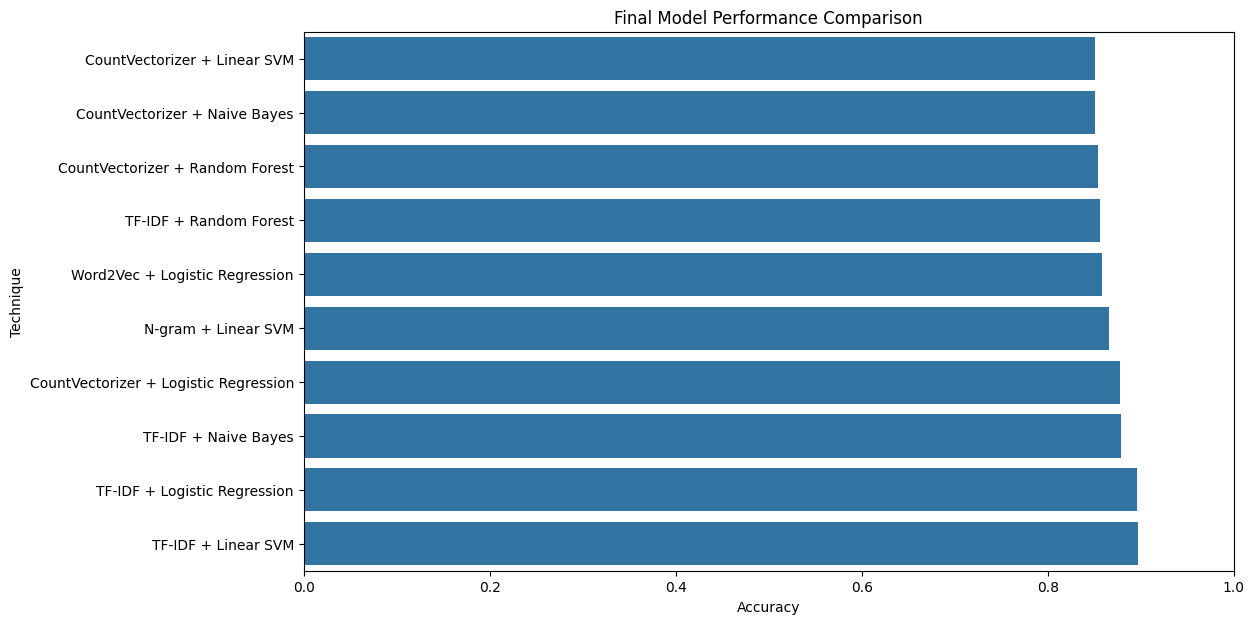

In [156]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x='Accuracy',
    y='Technique',
    data=final_results.sort_values('Accuracy')
)

plt.title('Final Model Performance Comparison')
plt.xlim(0, 1)
plt.show()

##Detailed Evaluation of Best Model

In [157]:
best_model_name = tfidf_results.loc[
    tfidf_results['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = tfidf_results['Accuracy'].max()

print("Best Model:", best_model_name)
print("Best Accuracy:", best_accuracy)

Best Model: Linear SVM
Best Accuracy: 0.8967429666229707


In [158]:
prediction_map = {
    'Logistic Regression': y_pred_lr_tfidf,
    'Naive Bayes': y_pred_nb_tfidf,
    'Linear SVM': y_pred_svm_tfidf,
    'Random Forest': y_pred_rf_tfidf
}

best_predictions = prediction_map[best_model_name]

##Classification Report

In [161]:
print("Classification Report")
print("=====================")

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=label_enc.classes_
    )
)

Classification Report
              precision    recall  f1-score   support

    negative       0.90      0.89      0.90      4940
    positive       0.89      0.90      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



##Confusion Matrix

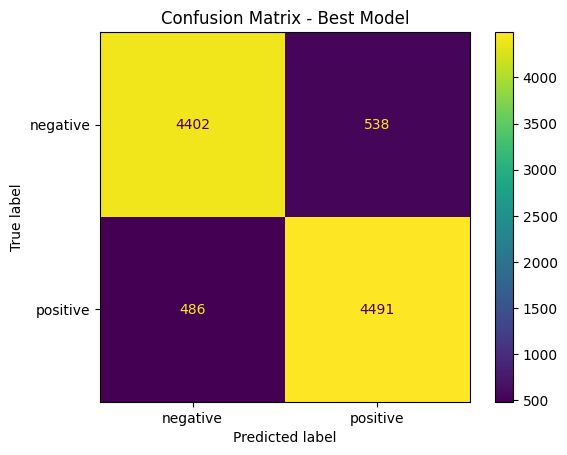

In [163]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_enc.classes_
)

disp.plot()

plt.title("Confusion Matrix - Best Model")
plt.show()

##Individual Evaluation Metrics

In [165]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(
    y_test,
    best_predictions,
    pos_label='positive'
)

recall = recall_score(
    y_test,
    best_predictions,
    pos_label='positive'
)

f1 = f1_score(
    y_test,
    best_predictions,
    pos_label='positive'
)

accuracy = accuracy_score(
    y_test,
    best_predictions
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8967429666229707
Precision: 0.8930204812089879
Recall   : 0.9023508137432188
F1 Score : 0.8976614031581052


##Predict a New Movie Review

In [170]:
models = {
    'Logistic Regression': lr_tfidf,
    'Naive Bayes': nb_tfidf,
    'Linear SVM': svm_tfidf,
    'Random Forest': rf_tfidf
}

best_model = models[best_model_name]

def lowercase_text(text):
    return text.lower()

def predict_sentiment(review_text):

    # Preprocessing
    review_text = remove_html(review_text)
    review_text = lowercase_text(review_text)
    review_text = remove_punctuation(review_text)

    tokens = word_tokenize(review_text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    cleaned_text = ' '.join(tokens)

    # Feature extraction
    review_vector = tfidf_vectorizer.transform(
        [cleaned_text]
    )

    # Prediction
    prediction = best_model.predict(review_vector)[0]

    # The prediction is already the sentiment string (e.g., 'positive', 'negative')
    # No need for inverse_transform if the model was trained with string labels
    sentiment = prediction

    return sentiment

In [171]:
review = """
This movie was absolutely fantastic. The acting was brilliant,
the story was engaging and I really enjoyed every moment of it.
"""

print("Predicted Sentiment:",
      predict_sentiment(review))

Predicted Sentiment: positive


In [172]:
review = """
This was one of the worst movies I have ever watched.
The story was boring, the acting was terrible and I hated it.
"""

print("Predicted Sentiment:",
      predict_sentiment(review))

Predicted Sentiment: negative


###